# Análise Exploratória de Dados (EDA)

Conjunto de dados: anúncios de venda de carros nos EUA (`vehicles_us.csv`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
car_data = pd.read_csv('../vehicles_us.csv')
car_data.head()

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
0,9400,2011.0,bmw x5,good,6.0,gas,145000.0,automatic,SUV,NaN,1.0,2018-06-23,19
1,25500,NaN,ford f-150,good,6.0,gas,88705.0,automatic,pickup,white,1.0,2018-10-19,50
2,5500,2013.0,hyundai sonata,like new,4.0,gas,110000.0,automatic,sedan,red,NaN,2019-02-07,79
3,1500,2003.0,ford f-150,fair,8.0,gas,NaN,automatic,pickup,NaN,NaN,2019-03-22,9
4,14900,2017.0,chrysler 200,excellent,4.0,gas,80903.0,automatic,sedan,black,NaN,2019-04-02,28


In [3]:
car_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  str    
 3   condition     51525 non-null  str    
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  str    
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  str    
 8   type          51525 non-null  str    
 9   paint_color   42258 non-null  str    
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  str    
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 5.1 MB


**Interpretação:** o conjunto tem 51.525 anúncios e 13 colunas. Cinco colunas têm valores ausentes: `model_year` (7,0%), `cylinders` (10,2%), `odometer` (15,3%), `paint_color` (18,0%) e, principalmente, `is_4wd` (50,4% ausente). As demais colunas (`price`, `model`, `condition`, `fuel`, `transmission`, `type`, `date_posted`, `days_listed`) estão completas.

In [4]:
car_data.describe()

,price,model_year,cylinders,odometer,is_4wd,days_listed
count,51525.000000,47906.000000,46265.000000,43633.000000,25572.0,51525.00000
mean,12132.464920,2009.750470,6.125235,115553.461738,1.0,39.55476
std,10040.803015,6.282065,1.660360,65094.611341,0.0,28.20427
min,1.000000,1908.000000,3.000000,0.000000,1.0,0.00000
25%,5000.000000,2006.000000,4.000000,70000.000000,1.0,19.00000
50%,9000.000000,2011.000000,6.000000,113000.000000,1.0,33.00000
75%,16839.000000,2014.000000,8.000000,155000.000000,1.0,53.00000
max,375000.000000,2019.000000,12.000000,990000.000000,1.0,271.00000


**Interpretação:** a média do preço (US\$ 12.132) é bem mais alta que a mediana (US\$ 9.000), o que indica uma distribuição assimétrica à direita — poucos anúncios com preços muito altos (até US\$ 375.000, com apenas 17 anúncios acima de US\$ 100.000) puxam a média para cima, enquanto a maior parte dos veículos é vendida por valores bem mais baixos.

## Tratamento de valores ausentes

Antes de seguir para as visualizações, decidimos o que fazer com cada coluna que tem valores ausentes. Não existe uma resposta única para cada caso — o importante é justificar a decisão:

- **`is_4wd`** (50,4% ausente): a coluna só tem o valor `1.0` ou vazio — nunca `0.0`. Isso sugere que o vazio não é um dado perdido, e sim que o anunciante simplesmente não marcou a opção porque o carro não tem tração 4x4 (quem tem, marca; quem não tem, deixa em branco). Por isso, preenchemos os ausentes com `0` em vez de descartar as linhas, já que descartá-las jogaria fora metade da base.
- **`paint_color`** (18,0% ausente): a cor não afeta diretamente a análise de preço/quilometragem deste notebook, e não há como inferir a cor real a partir de outras colunas. Preenchemos com `'unknown'` para preservar a linha sem inventar uma cor.
- **`odometer`** (15,3% ausente): é uma variável numérica central para a análise (aparece no histograma e no gráfico de dispersão). Preenchemos os ausentes com a **mediana** da coluna, que é mais robusta a outliers do que a média nesta distribuição.
- **`cylinders`** (10,2% ausente) e **`model_year`** (7,0% ausente): não são usadas nas visualizações deste notebook. Optamos por preenchê-las com a mediana (`cylinders`) e a moda (`model_year`) para manter a base completa, sem descartar anúncios.

In [5]:
car_data['is_4wd'] = car_data['is_4wd'].fillna(0)
car_data['paint_color'] = car_data['paint_color'].fillna('unknown')
car_data['odometer'] = car_data['odometer'].fillna(car_data['odometer'].median())
car_data['cylinders'] = car_data['cylinders'].fillna(car_data['cylinders'].median())
car_data['model_year'] = car_data['model_year'].fillna(car_data['model_year'].mode()[0])

car_data.isna().sum()

price           0
model_year      0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
transmission    0
type            0
paint_color     0
is_4wd          0
date_posted     0
days_listed     0
dtype: int64

**Interpretação:** depois do tratamento, todas as colunas ficam sem valores ausentes, prontas para as visualizações a seguir.

## Histograma da quilometragem (odometer)

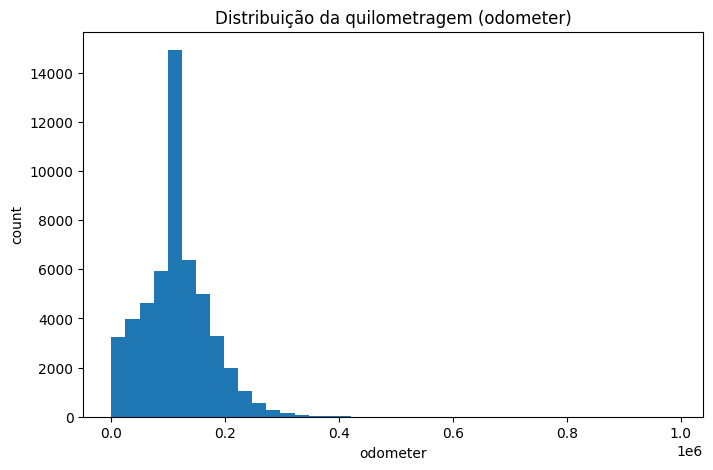

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(car_data['odometer'], bins=40)
plt.xlabel('odometer')
plt.ylabel('count')
plt.title('Distribuição da quilometragem (odometer)')
plt.show()

**Interpretação:** a quilometragem se concentra entre 70.000 e 155.000 milhas (25º e 75º percentil), com mediana em 113.000 milhas. A distribuição tem cauda longa à direita: existem 287 anúncios acima de 300.000 milhas, chegando a um máximo de 990.000 — valores extremos que provavelmente representam veículos comerciais ou erros de digitação. Também há 185 anúncios com odômetro igual a zero, o que é pouco provável para carros usados e pode indicar dado ausente preenchido incorretamente pelo próprio anunciante, e não quilometragem real.

## Gráfico de dispersão: quilometragem vs. preço

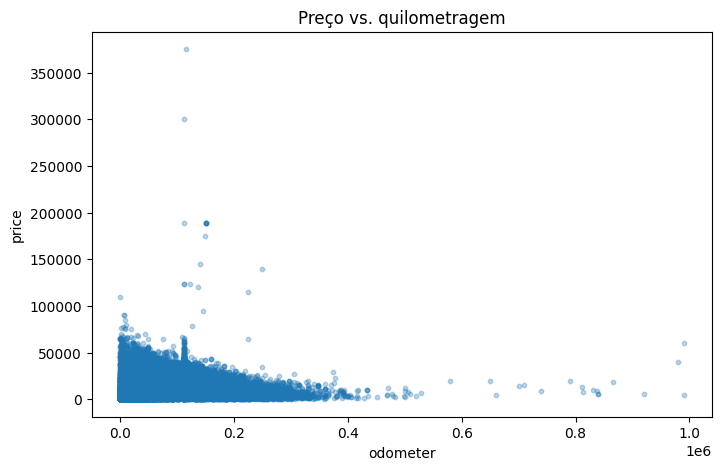

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(car_data['odometer'], car_data['price'], alpha=0.3, s=10)
plt.xlabel('odometer')
plt.ylabel('price')
plt.title('Preço vs. quilometragem')
plt.show()

**Interpretação:** existe uma correlação negativa moderada entre quilometragem e preço (coeficiente de correlação de aproximadamente -0,42): quanto maior o odômetro, menor tende a ser o preço, como esperado. A queda é mais acentuada nos primeiros 100.000 a 150.000 milhas, e depois desse ponto o preço tende a se estabilizar em valores baixos, formando uma espécie de "piso". Também aparecem pontos fora do padrão: alguns veículos com quilometragem baixa e preço muito alto (possivelmente carros de luxo ou colecionáveis), e outros com quilometragem altíssima que ainda mantêm preço acima do esperado (possivelmente caminhões ou veículos comerciais valorizados por outros atributos além do odômetro).

## Conclusão

O conjunto de dados de anúncios de carros contém 51.525 registros, com valores ausentes concentrados principalmente em `is_4wd`, `paint_color` e `odometer`. O tratamento aplicado (preenchimento com zero, `'unknown'`, mediana ou moda, conforme o significado de cada coluna) preserva o tamanho da base sem descartar metade dos anúncios, como aconteceria se simplesmente removêssemos as linhas com valores ausentes.

A análise de preço mostra uma distribuição assimétrica à direita, com poucos anúncios de altíssimo valor puxando a média para cima da mediana. A quilometragem também apresenta cauda longa, com um pequeno grupo de veículos com uso muito acima da média.

Por fim, o cruzamento entre quilometragem e preço confirma a relação esperada do mercado de usados — carros com mais quilometragem valem menos — mas com uma correlação apenas moderada (-0,42), o que indica que outros fatores (modelo, ano, condição, tipo do veículo) também têm peso relevante na formação do preço, e poderiam ser explorados em uma análise futura.